# Notebook 27 — Cross-mechanism Fingerprint Synthesis v0.1

## Goal

Build a cross-mechanism fingerprint synthesis for the `pybamm-aging-bridge` project.

This notebook consolidates already completed aging-mechanism audits into a unified mechanism-to-observable matrix and fitting-target hierarchy.

## Scientific context

The project has moved from isolated mechanism notebooks toward a mechanism-to-observable fingerprint framework for lithium-ion battery aging diagnostics and measurement-based aging-model parameterization.

The current mechanism branches are:

- SEI-only aging
- Contact / ohmic resistance growth
- LAM = Loss of Active Material（活性材料损失）
- Lithium plating（锂析出）

The central question is:

Which observable features are suitable as fitting targets（拟合目标）for which aging mechanisms?

## Protocol / study design

This notebook does not execute new PyBaMM simulations.

It synthesizes existing results from previous notebooks and documentation into:

- a mechanism fingerprint matrix
- a target hierarchy table
- rejection flags
- figures suitable for public-facing documentation
- a concise interpretation summary

## Workflow

1. Audit Python environment, repository state, and output paths.
2. Define the cross-mechanism evidence matrix.
3. Convert evidence into a fitting-target hierarchy.
4. Define rejection flags for non-qualified features.
5. Generate fingerprint heatmap and summary figures.
6. Save public-facing CSV, figures, and Markdown summary.
7. Close the notebook with interpretation boundaries and next steps.

## Expected outputs

Expected files:

- `data/cross_mechanism_fingerprint_matrix_v0_1.csv`
- `data/cross_mechanism_target_hierarchy_v0_1.csv`
- `data/cross_mechanism_rejection_flags_v0_1.csv`
- `figures/cross_mechanism_fingerprint_heatmap.png`
- `docs/tables/cross_mechanism_fingerprint_matrix_v0_1.csv`
- `docs/tables/cross_mechanism_target_hierarchy_v0_1.csv`
- `docs/tables/cross_mechanism_rejection_flags_v0_1.csv`
- `docs/figures/cross_mechanism_fingerprint_heatmap.png`
- `docs/cross_mechanism_fingerprint_synthesis_v0_1.md`

## Interpretation boundary

This notebook is a synthesis / reporting notebook.

It does not establish new mechanism evidence.

Lithium plating direct variables are treated as mechanism-state observables, not as closed external diagnostic fitting targets.

Public-facing outputs must remain company-neutral and must not mention specific OEM or company names.

In [1]:
# Cell 2 — Environment and repository audit（环境与仓库状态审计）

from pathlib import Path
import sys
import subprocess
import platform
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
expected_repo_name = "pybamm-aging-bridge"

# Robust repo-root detection
if cwd.name == expected_repo_name:
    repo = cwd
elif cwd.name == "notebooks" and cwd.parent.name == expected_repo_name:
    repo = cwd.parent
else:
    repo = cwd

print("[ENV] Python executable:")
print(sys.executable)

print("\n[ENV] Python version:")
print(sys.version)

print("\n[ENV] Platform:")
print(platform.platform())

print("\n[PATH] Notebook current working directory:")
print(cwd)

print("\n[PATH] Resolved repository root:")
print(repo)

if repo.name != expected_repo_name:
    print(f"[WARNING] Resolved repo name is '{repo.name}', expected '{expected_repo_name}'.")
else:
    print(f"[OK] Repository root resolved correctly: {repo}")

# Clean accidentally created empty output folders under notebooks/
wrong_roots = [
    cwd / "data",
    cwd / "figures",
    cwd / "docs",
]

if cwd.name == "notebooks":
    print("\n[CLEANUP] Checking accidentally created notebook-local output folders:")
    for wrong_root in wrong_roots:
        if wrong_root.exists():
            files_inside = [p for p in wrong_root.rglob("*") if p.is_file()]
            if files_inside:
                print(f"[WARNING] Not removing non-empty folder: {wrong_root}")
                for f in files_inside:
                    print(f"  contains file: {f}")
            else:
                shutil.rmtree(wrong_root)
                print(f"[OK] removed empty notebook-local folder: {wrong_root}")
        else:
            print(f"[OK] no notebook-local folder found: {wrong_root}")

print("\n[GIT] status:")
git_status = subprocess.run(
    ["git", "status", "--short"],
    cwd=repo,
    capture_output=True,
    text=True
)
print(git_status.stdout if git_status.stdout.strip() else "[OK] working tree clean")

print("\n[GIT] recent commits:")
git_log = subprocess.run(
    ["git", "log", "--oneline", "--max-count=8"],
    cwd=repo,
    capture_output=True,
    text=True
)
print(git_log.stdout)

# Correct output folders under repo root
data_dir = repo / "data"
fig_dir = repo / "figures"
docs_dir = repo / "docs"
docs_fig_dir = docs_dir / "figures"
docs_table_dir = docs_dir / "tables"

for path in [data_dir, fig_dir, docs_dir, docs_fig_dir, docs_table_dir]:
    path.mkdir(parents=True, exist_ok=True)
    print(f"[OK] ensured directory: {path}")

# Critical package audit
print("\n[PKG] Package versions:")
for pkg in ["pandas", "numpy", "matplotlib"]:
    try:
        mod = __import__(pkg)
        print(f"[OK] {pkg}: {mod.__version__}")
    except Exception as exc:
        print(f"[WARNING] {pkg}: not available ({exc})")

print("\n[BOUNDARY] Repository-safe neutrality policy:")
print("[OK] Notebook cells and generated outputs use company-neutral wording only.")
print("[OK] Organization-specific positioning is intentionally excluded from this notebook.")

# Final path sanity checks
assert repo.name == expected_repo_name, "Repository root was not resolved correctly."
assert data_dir.parent == repo, "data_dir is not under repository root."
assert docs_dir.parent == repo, "docs_dir is not under repository root."
assert fig_dir.parent == repo, "fig_dir is not under repository root."

print("\n[OK] Environment and repository audit completed.")

[ENV] Python executable:
/Users/louislu/projects/pybamm-aging-bridge/.venv/bin/python

[ENV] Python version:
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]

[ENV] Platform:
macOS-26.3.1-arm64-arm-64bit

[PATH] Notebook current working directory:
/Users/louislu/projects/pybamm-aging-bridge/notebooks

[PATH] Resolved repository root:
/Users/louislu/projects/pybamm-aging-bridge
[OK] Repository root resolved correctly: /Users/louislu/projects/pybamm-aging-bridge

[CLEANUP] Checking accidentally created notebook-local output folders:
[OK] no notebook-local folder found: /Users/louislu/projects/pybamm-aging-bridge/notebooks/data
[OK] no notebook-local folder found: /Users/louislu/projects/pybamm-aging-bridge/notebooks/figures
[OK] no notebook-local folder found: /Users/louislu/projects/pybamm-aging-bridge/notebooks/docs

[GIT] status:
 M docs/figures/cross_mechanism_fingerprint_heatmap.png
 M notebooks/27_cross_mechanism_fingerprint_synthesis.ipynb


[GIT] recent

## 1. Mechanism evidence matrix（机制证据矩阵）

This block defines the cross-mechanism evidence matrix used in the synthesis.

The matrix is manually constructed from already completed audit notebooks and documentation. No new simulation result is generated in this notebook.

Mechanism families included:

- SEI-only aging（SEI 单一老化分支）
- Contact / ohmic resistance growth（接触 / 欧姆内阻增长）
- NE-LAM = Negative Electrode Loss of Active Material（负极活性材料损失）
- PE-LAM = Positive Electrode Loss of Active Material（正极活性材料损失）
- Lithium plating（锂析出）

Observable classes included:

- Capacity RPT = Reference Performance Test（容量基准性能测试）
- Ri(t) = time-windowed internal resistance（时间窗内阻）
- C/25 central-window V(Q)（C/25 中央窗口电压曲线）
- GITT-like finite-rest voltage（GITT-like 有限静置电压）
- ICA = Incremental Capacity Analysis（增量容量分析）
- DVA = Differential Voltage Analysis（微分电压分析）
- corrected relaxation descriptors（校正后的弛豫描述符）
- endpoint / boundary indicators（端点 / 边界指标）
- direct plating-state variables（直接析锂状态变量）

Classification vocabulary:

| Classification | Meaning |
|---|---|
| primary | recommended as primary fitting target（主要拟合目标） |
| secondary | useful supporting target（次级拟合目标） |
| auxiliary | useful audit context but not primary evidence（辅助审计层） |
| rejected | not recommended as primary evidence（拒绝作为主要证据） |
| deferred | not yet closed（待完成） |

Important boundary:

Direct lithium plating variables are mechanism-state observables in the model. They are not equivalent to closed external diagnostic fitting targets.

In [2]:
# Cell 4 — Define and save mechanism evidence matrix（定义并保存机制证据矩阵）

classification_score = {
    "primary": 3,
    "secondary": 2,
    "auxiliary": 1,
    "rejected": 0,
    "deferred": np.nan,
}

rows = [
    # ------------------------------------------------------------------
    # SEI-only aging
    # ------------------------------------------------------------------
    {
        "mechanism": "SEI-only aging",
        "observable": "Capacity RPT",
        "classification": "primary",
        "evidence_strength": "strong",
        "evidence": "Capacity loss increases monotonically with SEI-only aging severity and provides the clearest measurable degradation response.",
        "interpretation_boundary": "Mechanism uniqueness requires contrast against other degradation mechanisms.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "C/25 central-window V(Q)",
        "classification": "secondary",
        "evidence_strength": "moderate",
        "evidence": "Central-window voltage drift is aging-sensitive and less boundary-dominated than full-window voltage comparison.",
        "interpretation_boundary": "Full-window voltage interpretation is endpoint-amplified and must not be used without central-window control.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "GITT-like finite-rest voltage",
        "classification": "secondary",
        "evidence_strength": "moderate but weak magnitude",
        "evidence": "Finite-rest voltage reconstruction is technically valid and less endpoint-amplified than full-window C/25 V(Q).",
        "interpretation_boundary": "Signal magnitude remains weak under current SEI-only severity.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "ICA central features",
        "classification": "rejected",
        "evidence_strength": "weak / unstable",
        "evidence": "ICA peak features are sensitive to preprocessing and do not qualify as primary SEI-only fitting targets.",
        "interpretation_boundary": "Can remain an auxiliary visualization layer only if smoothing sensitivity is explicitly audited.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "DVA central features",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "DVA descriptors are technically extractable but do not dominate the SEI-only response.",
        "interpretation_boundary": "Not recommended as primary SEI-only fitting target in the current evidence state.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "Ri(t)",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Resistance-related descriptors are not the dominant SEI-only fingerprint in the completed audits.",
        "interpretation_boundary": "Use as context rather than primary SEI-only evidence.",
    },
    {
        "mechanism": "SEI-only aging",
        "observable": "corrected relaxation descriptors",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Corrected relaxation descriptors provide secondary context but not dominant SEI-only separation.",
        "interpretation_boundary": "Not a primary fitting layer for the current SEI-only branch.",
    },

    # ------------------------------------------------------------------
    # Contact / ohmic resistance growth
    # ------------------------------------------------------------------
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "Ri(t)",
        "classification": "primary",
        "evidence_strength": "strong",
        "evidence": "All audited Ri(t) windows show near-exact additive increase equal to the imposed contact resistance.",
        "interpretation_boundary": "Use multi-window Ri(t); do not infer slow relaxation growth from raw voltage recovery amplitude.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "Capacity RPT",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Capacity impact is weak and mainly reflects usable-capacity boundary effects under tested resistance levels.",
        "interpretation_boundary": "Not recommended as a primary target for pure ohmic resistance growth.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "corrected relaxation descriptors",
        "classification": "rejected",
        "evidence_strength": "negative evidence",
        "evidence": "After post-ohmic correction, relaxation amplitude and time descriptors remain invariant across contact resistance levels.",
        "interpretation_boundary": "Raw recovery amplitude is ohmic-jump-confounded and must not be treated as slow relaxation evidence.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "raw recovery amplitude",
        "classification": "rejected",
        "evidence_strength": "artifact-confounded",
        "evidence": "Raw recovery amplitude changes because the instantaneous ohmic jump changes.",
        "interpretation_boundary": "Reject as primary relaxation descriptor unless post-ohmic correction is applied.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "C/25 central-window V(Q)",
        "classification": "deferred",
        "evidence_strength": "not audited",
        "evidence": "Not closed as a primary observable for this mechanism branch.",
        "interpretation_boundary": "No conclusion in the current synthesis.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "ICA central features",
        "classification": "deferred",
        "evidence_strength": "not audited",
        "evidence": "Not closed as a primary observable for this mechanism branch.",
        "interpretation_boundary": "No conclusion in the current synthesis.",
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "observable": "DVA central features",
        "classification": "deferred",
        "evidence_strength": "not audited",
        "evidence": "Not closed as a primary observable for this mechanism branch.",
        "interpretation_boundary": "No conclusion in the current synthesis.",
    },

    # ------------------------------------------------------------------
    # NE-LAM
    # ------------------------------------------------------------------
    {
        "mechanism": "NE-LAM",
        "observable": "Capacity RPT",
        "classification": "primary",
        "evidence_strength": "strong",
        "evidence": "NE-LAM produces strong capacity loss that scales with active-material loss severity.",
        "interpretation_boundary": "High NE-LAM levels are boundary-sensitive and must be interpreted with endpoint controls.",
    },
    {
        "mechanism": "NE-LAM",
        "observable": "C/25 central-window V(Q)",
        "classification": "secondary",
        "evidence_strength": "moderate",
        "evidence": "Central-window voltage drift increases with NE-LAM severity.",
        "interpretation_boundary": "Endpoint amplification appears at higher NE-LAM levels; central-window control is mandatory.",
    },
    {
        "mechanism": "NE-LAM",
        "observable": "DVA central features",
        "classification": "secondary",
        "evidence_strength": "moderate",
        "evidence": "DVA median central features become informative at stronger NE-LAM levels.",
        "interpretation_boundary": "Candidate fitting target only with smoothing and endpoint controls.",
    },
    {
        "mechanism": "NE-LAM",
        "observable": "ICA central features",
        "classification": "rejected",
        "evidence_strength": "unstable",
        "evidence": "ICA peak features remain unreliable as primary targets.",
        "interpretation_boundary": "Reject as primary fitting target because of preprocessing sensitivity.",
    },
    {
        "mechanism": "NE-LAM",
        "observable": "endpoint / boundary indicators",
        "classification": "auxiliary",
        "evidence_strength": "quality-control relevant",
        "evidence": "Endpoint amplification is visible at higher NE-LAM severity.",
        "interpretation_boundary": "Use as boundary warning, not as primary mechanism evidence.",
    },

    # ------------------------------------------------------------------
    # PE-LAM
    # ------------------------------------------------------------------
    {
        "mechanism": "PE-LAM",
        "observable": "C/25 central-window V(Q)",
        "classification": "primary",
        "evidence_strength": "strong",
        "evidence": "PE-LAM produces strong central voltage-shape drift without endpoint amplification in the tested range.",
        "interpretation_boundary": "Mechanism specificity still benefits from contrast against other branches.",
    },
    {
        "mechanism": "PE-LAM",
        "observable": "DVA central features",
        "classification": "primary",
        "evidence_strength": "strong",
        "evidence": "DVA median central features show strong signal-to-smoothing response and consistent direction under PE-LAM.",
        "interpretation_boundary": "Best derivative-layer candidate under the current LAM evidence.",
    },
    {
        "mechanism": "PE-LAM",
        "observable": "Capacity RPT",
        "classification": "secondary",
        "evidence_strength": "moderate",
        "evidence": "Capacity effect is present but weaker than the voltage-shape response.",
        "interpretation_boundary": "Not the dominant PE-LAM fingerprint in the current branch.",
    },
    {
        "mechanism": "PE-LAM",
        "observable": "ICA central features",
        "classification": "rejected",
        "evidence_strength": "unstable",
        "evidence": "ICA peak features remain unreliable as primary targets.",
        "interpretation_boundary": "Reject as primary fitting target because of peak-position and smoothing sensitivity.",
    },
    {
        "mechanism": "PE-LAM",
        "observable": "endpoint / boundary indicators",
        "classification": "auxiliary",
        "evidence_strength": "quality-control relevant",
        "evidence": "Endpoint amplification flag remains false in the tested PE-LAM range.",
        "interpretation_boundary": "Use as quality-control context, not as primary fitting target.",
    },

    # ------------------------------------------------------------------
    # Lithium plating
    # ------------------------------------------------------------------
    {
        "mechanism": "Lithium plating",
        "observable": "direct plating-state variables",
        "classification": "primary",
        "evidence_strength": "strong for model-state observability",
        "evidence": "Direct plating-state variables show stress sensitivity and clean matched-control separation.",
        "interpretation_boundary": "These are model-state observables, not closed external diagnostic fitting targets.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "Capacity RPT",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Matched post-stress capacity differences are present but small under the tested stress cases.",
        "interpretation_boundary": "Partially reversible plating means direct plating amount is not equivalent to irreversible capacity loss.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "Ri(t)",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Process-isolated HPPC audit shows weak matched plating-minus-control Ri(t) shifts.",
        "interpretation_boundary": "Direct plating observability does not imply a resistance-growth-like external fingerprint.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "corrected relaxation descriptors",
        "classification": "auxiliary",
        "evidence_strength": "weak",
        "evidence": "Corrected relaxation shifts remain weak in the tested HPPC workflow.",
        "interpretation_boundary": "Not qualified as primary plating fingerprint under current evidence.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "C/25 central-window V(Q)",
        "classification": "deferred",
        "evidence_strength": "not closed",
        "evidence": "Full voltage-curve plating fingerprint remains open.",
        "interpretation_boundary": "Requires future process-isolated diagnostic audit.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "GITT-like finite-rest voltage",
        "classification": "deferred",
        "evidence_strength": "not closed",
        "evidence": "Finite-rest plating voltage fingerprint remains open.",
        "interpretation_boundary": "Requires future process-isolated diagnostic audit.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "ICA central features",
        "classification": "deferred",
        "evidence_strength": "not closed",
        "evidence": "Derivative-layer plating fingerprint remains open.",
        "interpretation_boundary": "Requires future process-isolated diagnostic audit.",
    },
    {
        "mechanism": "Lithium plating",
        "observable": "DVA central features",
        "classification": "deferred",
        "evidence_strength": "not closed",
        "evidence": "Derivative-layer plating fingerprint remains open.",
        "interpretation_boundary": "Requires future process-isolated diagnostic audit.",
    },
]

fingerprint_df = pd.DataFrame(rows)
fingerprint_df["score"] = fingerprint_df["classification"].map(classification_score)

# Column order
fingerprint_df = fingerprint_df[
    [
        "mechanism",
        "observable",
        "classification",
        "score",
        "evidence_strength",
        "evidence",
        "interpretation_boundary",
    ]
]

# Save outputs
matrix_data_path = data_dir / "cross_mechanism_fingerprint_matrix_v0_1.csv"
matrix_docs_path = docs_table_dir / "cross_mechanism_fingerprint_matrix_v0_1.csv"

fingerprint_df.to_csv(matrix_data_path, index=False)
fingerprint_df.to_csv(matrix_docs_path, index=False)

print(f"[OK] saved data matrix: {matrix_data_path}")
print(f"[OK] saved docs matrix: {matrix_docs_path}")

# Visible audit summary
summary_table = (
    fingerprint_df
    .groupby(["mechanism", "classification"], dropna=False)
    .size()
    .reset_index(name="n_observables")
    .sort_values(["mechanism", "classification"])
)

print("\n[OK] Evidence matrix shape:")
print(fingerprint_df.shape)

print("\n[OK] Classification summary:")
display(summary_table)

print("\n[OK] Full mechanism evidence matrix:")
display(fingerprint_df)

# Boundary warnings
print("\n[BOUNDARY CHECKS]")
print("[OK] No new simulation evidence is introduced in this matrix.")
print("[OK] Lithium plating direct variables are classified as model-state observables.")
print("[OK] External lithium-plating diagnostic fingerprint remains deferred where not yet audited.")

[OK] saved data matrix: /Users/louislu/projects/pybamm-aging-bridge/data/cross_mechanism_fingerprint_matrix_v0_1.csv
[OK] saved docs matrix: /Users/louislu/projects/pybamm-aging-bridge/docs/tables/cross_mechanism_fingerprint_matrix_v0_1.csv

[OK] Evidence matrix shape:
(32, 7)

[OK] Classification summary:


,mechanism,classification,n_observables
0,Contact / ohmic resistance growth,auxiliary,1
1,Contact / ohmic resistance growth,deferred,3
2,Contact / ohmic resistance growth,primary,1
3,Contact / ohmic resistance growth,rejected,2
4,Lithium plating,auxiliary,3
5,Lithium plating,deferred,4
6,Lithium plating,primary,1
7,NE-LAM,auxiliary,1
8,NE-LAM,primary,1
9,NE-LAM,rejected,1



[OK] Full mechanism evidence matrix:


,mechanism,observable,classification,score,evidence_strength,evidence,interpretation_boundary
0,SEI-only aging,Capacity RPT,primary,3.0,strong,Capacity loss increases monotonically with SEI...,Mechanism uniqueness requires contrast against...
1,SEI-only aging,C/25 central-window V(Q),secondary,2.0,moderate,Central-window voltage drift is aging-sensitiv...,Full-window voltage interpretation is endpoint...
2,SEI-only aging,GITT-like finite-rest voltage,secondary,2.0,moderate but weak magnitude,Finite-rest voltage reconstruction is technica...,Signal magnitude remains weak under current SE...
3,SEI-only aging,ICA central features,rejected,0.0,weak / unstable,ICA peak features are sensitive to preprocessi...,Can remain an auxiliary visualization layer on...
4,SEI-only aging,DVA central features,auxiliary,1.0,weak,DVA descriptors are technically extractable bu...,Not recommended as primary SEI-only fitting ta...
5,SEI-only aging,Ri(t),auxiliary,1.0,weak,Resistance-related descriptors are not the dom...,Use as context rather than primary SEI-only ev...
6,SEI-only aging,corrected relaxation descriptors,auxiliary,1.0,weak,Corrected relaxation descriptors provide secon...,Not a primary fitting layer for the current SE...
7,Contact / ohmic resistance growth,Ri(t),primary,3.0,strong,All audited Ri(t) windows show near-exact addi...,Use multi-window Ri(t); do not infer slow rela...
8,Contact / ohmic resistance growth,Capacity RPT,auxiliary,1.0,weak,Capacity impact is weak and mainly reflects us...,Not recommended as a primary target for pure o...
9,Contact / ohmic resistance growth,corrected relaxation descriptors,rejected,0.0,negative evidence,"After post-ohmic correction, relaxation amplit...",Raw recovery amplitude is ohmic-jump-confounde...



[BOUNDARY CHECKS]
[OK] No new simulation evidence is introduced in this matrix.
[OK] Lithium plating direct variables are classified as model-state observables.
[OK] External lithium-plating diagnostic fingerprint remains deferred where not yet audited.


## 2. Fitting-target hierarchy（拟合目标层级）

This block converts the mechanism evidence matrix into a mechanism-level fitting-target hierarchy.

The purpose is to distinguish:

- primary fitting targets（主要拟合目标）
- secondary fitting targets（次级拟合目标）
- auxiliary audit layers（辅助审计层）
- rejected features（拒绝作为主要证据的特征）
- deferred features（尚未闭合的特征）

The hierarchy is intentionally conservative.

A feature can be measurable and still not qualify as a primary fitting target if it is:

- endpoint-amplified（端点放大）
- smoothing-sensitive（平滑敏感）
- weakly linked to the degradation-state variable（与退化状态变量关联较弱）
- mechanism-non-unique（机制非唯一）
- below protocol sensitivity（低于协议灵敏度）
- only available as a model-state variable（仅作为模型状态变量可得）

Important boundary:

For lithium plating, direct plating-state variables are classified as primary mechanism-state observables. External diagnostic fitting targets remain deferred unless supported by measurement-accessible features.

In [3]:
# Cell 6 — Build and save fitting-target hierarchy（构建并保存拟合目标层级）

target_rows = [
    {
        "mechanism": "SEI-only aging",
        "primary_targets": "Capacity RPT",
        "secondary_targets": "C/25 central-window V(Q); GITT-like finite-rest voltage",
        "auxiliary_layers": "DVA central features; Ri(t); corrected relaxation descriptors",
        "rejected_features": "ICA central features; endpoint-only voltage drift",
        "deferred_features": "None in current SEI-only branch",
        "correct_conclusion_wording": (
            "SEI-only aging is capacity-dominant, with secondary voltage sensitivity "
            "and derivative features remaining auxiliary under the current evidence."
        ),
        "main_boundary": (
            "Mechanism uniqueness is not guaranteed by capacity alone; contrast branches are required."
        ),
    },
    {
        "mechanism": "Contact / ohmic resistance growth",
        "primary_targets": "Multi-window Ri(t)",
        "secondary_targets": "None currently recommended",
        "auxiliary_layers": "Capacity RPT",
        "rejected_features": "raw recovery amplitude; corrected relaxation descriptors as primary evidence",
        "deferred_features": "C/25 central-window V(Q); ICA central features; DVA central features",
        "correct_conclusion_wording": (
            "Contact / ohmic resistance growth is Ri(t)-dominant and post-ohmic-relaxation-invariant."
        ),
        "main_boundary": (
            "Raw recovery amplitude is ohmic-jump-confounded and must not be interpreted "
            "as slow relaxation evidence."
        ),
    },
    {
        "mechanism": "NE-LAM",
        "primary_targets": "Capacity RPT",
        "secondary_targets": "C/25 central-window V(Q); DVA central features",
        "auxiliary_layers": "endpoint / boundary indicators",
        "rejected_features": "ICA central features; endpoint-only signal",
        "deferred_features": "None in current NE-LAM branch",
        "correct_conclusion_wording": (
            "NE-LAM is capacity-dominant and boundary-sensitive, with secondary voltage-shape "
            "and DVA information under controlled central-window evaluation."
        ),
        "main_boundary": (
            "Higher NE-LAM severity can introduce endpoint amplification; central-window control is mandatory."
        ),
    },
    {
        "mechanism": "PE-LAM",
        "primary_targets": "C/25 central-window V(Q); DVA central features",
        "secondary_targets": "Capacity RPT",
        "auxiliary_layers": "endpoint / boundary indicators",
        "rejected_features": "ICA central features",
        "deferred_features": "None in current PE-LAM branch",
        "correct_conclusion_wording": (
            "PE-LAM is voltage-shape- and DVA-dominant within the tested range, "
            "with capacity serving as a secondary target."
        ),
        "main_boundary": (
            "Mechanism specificity still requires contrast against other voltage-shape-producing mechanisms."
        ),
    },
    {
        "mechanism": "Lithium plating",
        "primary_targets": "direct plating-state variables",
        "secondary_targets": "None closed as external diagnostic targets",
        "auxiliary_layers": "Capacity RPT; Ri(t); corrected relaxation descriptors",
        "rejected_features": "None as universal rejection; current external signals are weak rather than disproven",
        "deferred_features": "C/25 central-window V(Q); GITT-like finite-rest voltage; ICA central features; DVA central features",
        "correct_conclusion_wording": (
            "Lithium plating direct model-state observability is supported, while the external "
            "diagnostic fingerprint remains deferred under the current evidence."
        ),
        "main_boundary": (
            "Direct plating variables are mechanism-state observables and must not be equated "
            "with closed measurement-accessible fitting targets."
        ),
    },
]

target_hierarchy_df = pd.DataFrame(target_rows)

target_data_path = data_dir / "cross_mechanism_target_hierarchy_v0_1.csv"
target_docs_path = docs_table_dir / "cross_mechanism_target_hierarchy_v0_1.csv"

target_hierarchy_df.to_csv(target_data_path, index=False)
target_hierarchy_df.to_csv(target_docs_path, index=False)

print(f"[OK] saved data target hierarchy: {target_data_path}")
print(f"[OK] saved docs target hierarchy: {target_docs_path}")

print("\n[OK] Target hierarchy shape:")
print(target_hierarchy_df.shape)

print("\n[OK] Mechanism-level fitting-target hierarchy:")
display(target_hierarchy_df)

# Compact display for audit readability
compact_target_df = target_hierarchy_df[
    [
        "mechanism",
        "primary_targets",
        "secondary_targets",
        "auxiliary_layers",
        "deferred_features",
    ]
].copy()

print("\n[OK] Compact target hierarchy:")
display(compact_target_df)

# Assertions against overclaiming
plating_row = target_hierarchy_df[target_hierarchy_df["mechanism"] == "Lithium plating"].iloc[0]

assert "deferred" in plating_row["correct_conclusion_wording"], (
    "Lithium plating conclusion must state that the external diagnostic fingerprint remains deferred."
)

assert "mechanism-state observables" in plating_row["main_boundary"], (
    "Lithium plating boundary must distinguish direct variables from measurement-accessible targets."
)

assert target_hierarchy_df["primary_targets"].notna().all(), (
    "Each mechanism must have an explicitly stated primary target or primary mechanism-state observable."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Lithium plating external diagnostic fingerprint remains deferred.")
print("[OK] Direct plating variables are separated from measurement-accessible fitting targets.")
print("[OK] Every mechanism has an explicit primary target layer or primary mechanism-state observable.")

[OK] saved data target hierarchy: /Users/louislu/projects/pybamm-aging-bridge/data/cross_mechanism_target_hierarchy_v0_1.csv
[OK] saved docs target hierarchy: /Users/louislu/projects/pybamm-aging-bridge/docs/tables/cross_mechanism_target_hierarchy_v0_1.csv

[OK] Target hierarchy shape:
(5, 8)

[OK] Mechanism-level fitting-target hierarchy:


,mechanism,primary_targets,secondary_targets,auxiliary_layers,rejected_features,deferred_features,correct_conclusion_wording,main_boundary
0,SEI-only aging,Capacity RPT,C/25 central-window V(Q); GITT-like finite-res...,DVA central features; Ri(t); corrected relaxat...,ICA central features; endpoint-only voltage drift,None in current SEI-only branch,"SEI-only aging is capacity-dominant, with seco...",Mechanism uniqueness is not guaranteed by capa...
1,Contact / ohmic resistance growth,Multi-window Ri(t),None currently recommended,Capacity RPT,raw recovery amplitude; corrected relaxation d...,C/25 central-window V(Q); ICA central features...,Contact / ohmic resistance growth is Ri(t)-dom...,Raw recovery amplitude is ohmic-jump-confounde...
2,NE-LAM,Capacity RPT,C/25 central-window V(Q); DVA central features,endpoint / boundary indicators,ICA central features; endpoint-only signal,None in current NE-LAM branch,NE-LAM is capacity-dominant and boundary-sensi...,Higher NE-LAM severity can introduce endpoint ...
3,PE-LAM,C/25 central-window V(Q); DVA central features,Capacity RPT,endpoint / boundary indicators,ICA central features,None in current PE-LAM branch,PE-LAM is voltage-shape- and DVA-dominant with...,Mechanism specificity still requires contrast ...
4,Lithium plating,direct plating-state variables,None closed as external diagnostic targets,Capacity RPT; Ri(t); corrected relaxation desc...,None as universal rejection; current external ...,C/25 central-window V(Q); GITT-like finite-res...,Lithium plating direct model-state observabili...,Direct plating variables are mechanism-state o...



[OK] Compact target hierarchy:


,mechanism,primary_targets,secondary_targets,auxiliary_layers,deferred_features
0,SEI-only aging,Capacity RPT,C/25 central-window V(Q); GITT-like finite-res...,DVA central features; Ri(t); corrected relaxat...,None in current SEI-only branch
1,Contact / ohmic resistance growth,Multi-window Ri(t),None currently recommended,Capacity RPT,C/25 central-window V(Q); ICA central features...
2,NE-LAM,Capacity RPT,C/25 central-window V(Q); DVA central features,endpoint / boundary indicators,None in current NE-LAM branch
3,PE-LAM,C/25 central-window V(Q); DVA central features,Capacity RPT,endpoint / boundary indicators,None in current PE-LAM branch
4,Lithium plating,direct plating-state variables,None closed as external diagnostic targets,Capacity RPT; Ri(t); corrected relaxation desc...,C/25 central-window V(Q); GITT-like finite-res...



[BOUNDARY CHECKS]
[OK] Lithium plating external diagnostic fingerprint remains deferred.
[OK] Direct plating variables are separated from measurement-accessible fitting targets.
[OK] Every mechanism has an explicit primary target layer or primary mechanism-state observable.


## 3. Rejection flag registry（拒绝标记注册表）

This block defines the feature-rejection and downgrade logic used in the cross-mechanism synthesis.

The purpose is to prevent artifact-driven fitting.

A measurable feature is not automatically a valid fitting target（拟合目标）. It can be rejected or downgraded if the observed signal is dominated by:

- endpoint amplification（端点放大 / 截止边界放大）
- smoothing sensitivity（平滑敏感性）
- weak matched-control separation（匹配对照差异较弱）
- mechanism non-uniqueness（机制非唯一性）
- protocol sensitivity（协议敏感性）
- ohmic-jump confounding（欧姆跳变混杂）
- model-state-only observability（仅模型状态变量可观测）

This registry is used as an audit layer, not as a new simulation result.

In [4]:
# Cell 8 — Build and save rejection flag registry（构建并保存拒绝标记注册表）

rejection_flag_rows = [
    {
        "flag_id": "endpoint_amplification",
        "flag_name": "endpoint amplification",
        "definition": (
            "The observable changes mainly near voltage, capacity, or cutoff boundaries rather than "
            "over the central state window."
        ),
        "risk": (
            "The feature may reflect cutoff-boundary movement, usable-capacity shift, or endpoint curvature "
            "instead of a mechanism-specific aging response."
        ),
        "audit_action": (
            "Require central-window evaluation and endpoint-exclusion control before using the feature."
        ),
        "recommended_decision": "downgrade_or_reject_as_primary",
        "example_observable_layer": "full-window V(Q), endpoint-only derivative features",
    },
    {
        "flag_id": "smoothing_sensitivity",
        "flag_name": "smoothing sensitivity",
        "definition": (
            "The observable magnitude, direction, or peak position changes substantially across smoothing settings."
        ),
        "risk": (
            "The extracted feature may be a preprocessing artifact rather than a stable physical descriptor."
        ),
        "audit_action": (
            "Run smoothing-window sensitivity and require stable direction and sufficient signal-to-smoothing ratio."
        ),
        "recommended_decision": "reject_as_primary_if_unstable",
        "example_observable_layer": "ICA peak features, derivative peak locations",
    },
    {
        "flag_id": "weak_matched_control_separation",
        "flag_name": "weak matched-control separation",
        "definition": (
            "The mechanism-enabled branch differs only weakly from its matched control under the same protocol."
        ),
        "risk": (
            "The signal may fall below protocol sensitivity or be dominated by temperature, initialization, or solver noise."
        ),
        "audit_action": (
            "Report matched deltas explicitly and classify the feature as auxiliary if the matched effect is weak."
        ),
        "recommended_decision": "downgrade_to_auxiliary",
        "example_observable_layer": "plating-minus-control Ri(t), corrected relaxation deltas",
    },
    {
        "flag_id": "mechanism_non_uniqueness",
        "flag_name": "mechanism non-uniqueness",
        "definition": (
            "The same observable can plausibly be produced by multiple degradation mechanisms."
        ),
        "risk": (
            "A fitting procedure may assign the correct signal to the wrong mechanism."
        ),
        "audit_action": (
            "Require contrast branches or multi-objective evidence before assigning mechanism specificity."
        ),
        "recommended_decision": "use_only_with_contrast_evidence",
        "example_observable_layer": "capacity fade, voltage-shape drift, resistance increase",
    },
    {
        "flag_id": "ohmic_jump_confounding",
        "flag_name": "ohmic-jump confounding",
        "definition": (
            "The observable changes because the instantaneous I·R voltage jump changes, not because slow relaxation changes."
        ),
        "risk": (
            "Raw recovery amplitude can be misinterpreted as relaxation growth."
        ),
        "audit_action": (
            "Use post-ohmic corrected relaxation descriptors before interpreting recovery behavior."
        ),
        "recommended_decision": "reject_raw_feature_as_primary",
        "example_observable_layer": "raw recovery amplitude, raw recovery area",
    },
    {
        "flag_id": "model_state_only_observability",
        "flag_name": "model-state-only observability",
        "definition": (
            "The feature is directly available as an internal model variable but is not directly measurement-accessible."
        ),
        "risk": (
            "Mechanism-state observability may be incorrectly presented as an external diagnostic fingerprint."
        ),
        "audit_action": (
            "Separate direct mechanism-state observability from external measurement-accessible fitting targets."
        ),
        "recommended_decision": "separate_from_external_fitting_targets",
        "example_observable_layer": "direct plating-state variables",
    },
    {
        "flag_id": "protocol_sensitivity",
        "flag_name": "protocol sensitivity",
        "definition": (
            "The feature depends strongly on diagnostic protocol settings such as rate, rest duration, Q-window, or cutoff."
        ),
        "risk": (
            "The feature may not transfer across diagnostic protocols or operating windows."
        ),
        "audit_action": (
            "State the protocol boundary and require cross-protocol validation before primary-target use."
        ),
        "recommended_decision": "downgrade_until_cross_protocol_validated",
        "example_observable_layer": "OCV-like V(Q), GITT-like finite-rest voltage, derivative features",
    },
    {
        "flag_id": "execution_resource_boundary",
        "flag_name": "execution-resource boundary",
        "definition": (
            "The workflow failed or was constrained because of execution-resource limits rather than physical evidence."
        ),
        "risk": (
            "A computational failure may be misclassified as a scientific negative result."
        ),
        "audit_action": (
            "Move the workflow to process-isolated execution or reduce memory pressure before drawing physical conclusions."
        ),
        "recommended_decision": "defer_scientific_claim",
        "example_observable_layer": "large DFN diagnostic workflows with dense HPPC sampling",
    },
]

rejection_flags_df = pd.DataFrame(rejection_flag_rows)

rejection_data_path = data_dir / "cross_mechanism_rejection_flags_v0_1.csv"
rejection_docs_path = docs_table_dir / "cross_mechanism_rejection_flags_v0_1.csv"

rejection_flags_df.to_csv(rejection_data_path, index=False)
rejection_flags_df.to_csv(rejection_docs_path, index=False)

print(f"[OK] saved data rejection flags: {rejection_data_path}")
print(f"[OK] saved docs rejection flags: {rejection_docs_path}")

print("\n[OK] Rejection flag registry shape:")
print(rejection_flags_df.shape)

print("\n[OK] Rejection flag registry:")
display(rejection_flags_df)

# Compact display for audit readability
compact_rejection_flags_df = rejection_flags_df[
    [
        "flag_id",
        "flag_name",
        "recommended_decision",
        "example_observable_layer",
    ]
].copy()

print("\n[OK] Compact rejection flag registry:")
display(compact_rejection_flags_df)

# Assertion checks
required_flags = {
    "endpoint_amplification",
    "smoothing_sensitivity",
    "weak_matched_control_separation",
    "mechanism_non_uniqueness",
    "ohmic_jump_confounding",
    "model_state_only_observability",
    "protocol_sensitivity",
    "execution_resource_boundary",
}

observed_flags = set(rejection_flags_df["flag_id"])
missing_flags = required_flags - observed_flags

assert not missing_flags, f"Missing required rejection flags: {missing_flags}"

assert (
    rejection_flags_df["flag_id"].is_unique
), "flag_id values must be unique."

assert (
    rejection_flags_df["recommended_decision"].notna().all()
), "Every rejection flag must have a recommended decision."

print("\n[BOUNDARY CHECKS]")
print("[OK] Required rejection flags are present.")
print("[OK] Each rejection flag has a unique ID.")
print("[OK] Each rejection flag has an explicit audit decision.")
print("[OK] Registry is an interpretation-control layer, not new simulation evidence.")

[OK] saved data rejection flags: /Users/louislu/projects/pybamm-aging-bridge/data/cross_mechanism_rejection_flags_v0_1.csv
[OK] saved docs rejection flags: /Users/louislu/projects/pybamm-aging-bridge/docs/tables/cross_mechanism_rejection_flags_v0_1.csv

[OK] Rejection flag registry shape:
(8, 7)

[OK] Rejection flag registry:


,flag_id,flag_name,definition,risk,audit_action,recommended_decision,example_observable_layer
0,endpoint_amplification,endpoint amplification,"The observable changes mainly near voltage, ca...",The feature may reflect cutoff-boundary moveme...,Require central-window evaluation and endpoint...,downgrade_or_reject_as_primary,"full-window V(Q), endpoint-only derivative fea..."
1,smoothing_sensitivity,smoothing sensitivity,"The observable magnitude, direction, or peak p...",The extracted feature may be a preprocessing a...,Run smoothing-window sensitivity and require s...,reject_as_primary_if_unstable,"ICA peak features, derivative peak locations"
2,weak_matched_control_separation,weak matched-control separation,The mechanism-enabled branch differs only weak...,The signal may fall below protocol sensitivity...,Report matched deltas explicitly and classify ...,downgrade_to_auxiliary,"plating-minus-control Ri(t), corrected relaxat..."
3,mechanism_non_uniqueness,mechanism non-uniqueness,The same observable can plausibly be produced ...,A fitting procedure may assign the correct sig...,Require contrast branches or multi-objective e...,use_only_with_contrast_evidence,"capacity fade, voltage-shape drift, resistance..."
4,ohmic_jump_confounding,ohmic-jump confounding,The observable changes because the instantaneo...,Raw recovery amplitude can be misinterpreted a...,Use post-ohmic corrected relaxation descriptor...,reject_raw_feature_as_primary,"raw recovery amplitude, raw recovery area"
5,model_state_only_observability,model-state-only observability,The feature is directly available as an intern...,Mechanism-state observability may be incorrect...,Separate direct mechanism-state observability ...,separate_from_external_fitting_targets,direct plating-state variables
6,protocol_sensitivity,protocol sensitivity,The feature depends strongly on diagnostic pro...,The feature may not transfer across diagnostic...,State the protocol boundary and require cross-...,downgrade_until_cross_protocol_validated,"OCV-like V(Q), GITT-like finite-rest voltage, ..."
7,execution_resource_boundary,execution-resource boundary,The workflow failed or was constrained because...,A computational failure may be misclassified a...,Move the workflow to process-isolated executio...,defer_scientific_claim,large DFN diagnostic workflows with dense HPPC...



[OK] Compact rejection flag registry:


,flag_id,flag_name,recommended_decision,example_observable_layer
0,endpoint_amplification,endpoint amplification,downgrade_or_reject_as_primary,"full-window V(Q), endpoint-only derivative fea..."
1,smoothing_sensitivity,smoothing sensitivity,reject_as_primary_if_unstable,"ICA peak features, derivative peak locations"
2,weak_matched_control_separation,weak matched-control separation,downgrade_to_auxiliary,"plating-minus-control Ri(t), corrected relaxat..."
3,mechanism_non_uniqueness,mechanism non-uniqueness,use_only_with_contrast_evidence,"capacity fade, voltage-shape drift, resistance..."
4,ohmic_jump_confounding,ohmic-jump confounding,reject_raw_feature_as_primary,"raw recovery amplitude, raw recovery area"
5,model_state_only_observability,model-state-only observability,separate_from_external_fitting_targets,direct plating-state variables
6,protocol_sensitivity,protocol sensitivity,downgrade_until_cross_protocol_validated,"OCV-like V(Q), GITT-like finite-rest voltage, ..."
7,execution_resource_boundary,execution-resource boundary,defer_scientific_claim,large DFN diagnostic workflows with dense HPPC...



[BOUNDARY CHECKS]
[OK] Required rejection flags are present.
[OK] Each rejection flag has a unique ID.
[OK] Each rejection flag has an explicit audit decision.
[OK] Registry is an interpretation-control layer, not new simulation evidence.


## 4. Visualization audit（可视化审计）

This block generates company-neutral, documentation-ready figures from the synthesis tables.

Figures are used as audit objects:

1. The fingerprint heatmap checks whether each mechanism has a distinct observable hierarchy.
2. The classification-count plot checks whether any mechanism is overclaimed by too many primary features.
3. The target hierarchy overview checks whether the recommended fitting targets remain conservative.

Numerical encoding for the heatmap:

| Value | Classification |
|---:|---|
| 3 | primary |
| 2 | secondary |
| 1 | auxiliary |
| 0 | rejected |
| -1 | deferred |

Boundary:

The figures summarize existing evidence only. They do not introduce new simulation or diagnostic results.

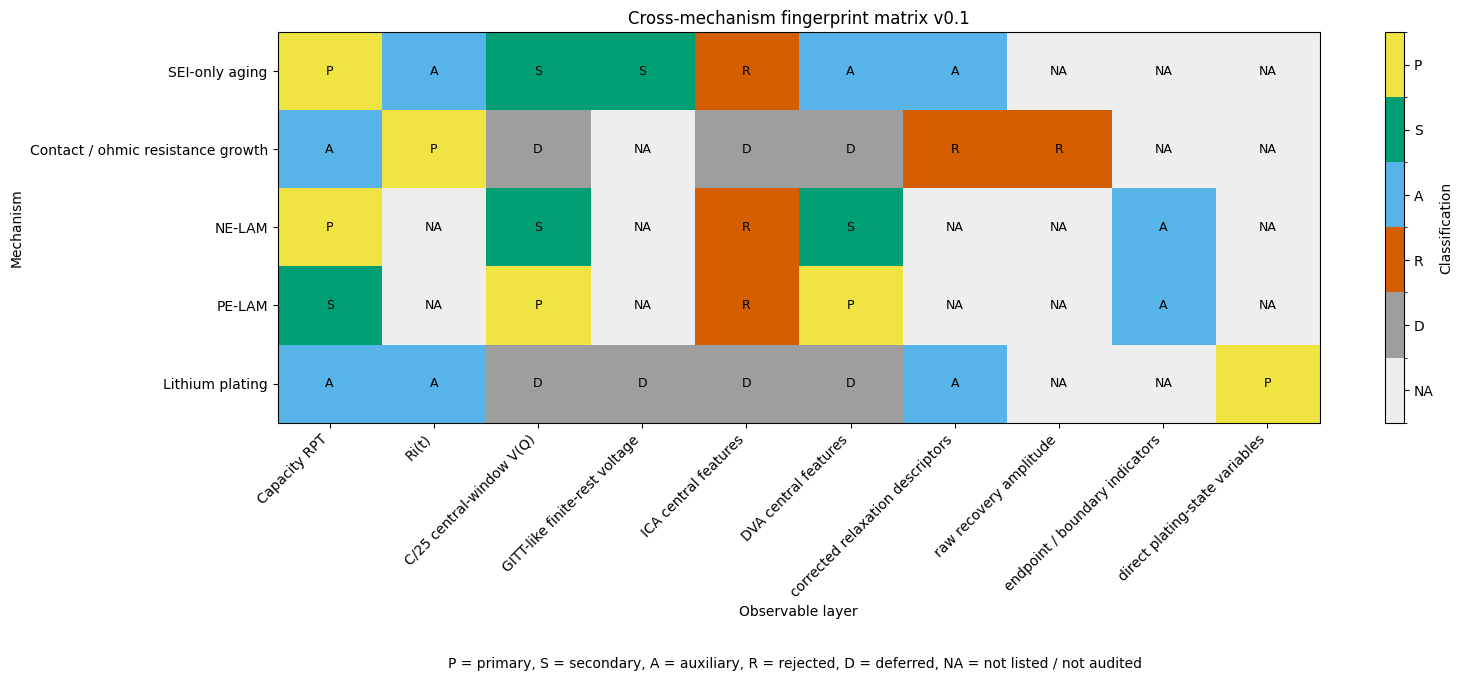

[OK] saved heatmap figure: /Users/louislu/projects/pybamm-aging-bridge/figures/cross_mechanism_fingerprint_heatmap.png
[OK] saved docs heatmap figure: /Users/louislu/projects/pybamm-aging-bridge/docs/figures/cross_mechanism_fingerprint_heatmap.png

[OK] Heatmap matrix used for plotting:


observable,Capacity RPT,Ri(t),C/25 central-window V(Q),GITT-like finite-rest voltage,ICA central features,DVA central features,corrected relaxation descriptors,raw recovery amplitude,endpoint / boundary indicators,direct plating-state variables
mechanism,,,,,,,,,,
SEI-only aging,3.0,1.0,2.0,2.0,0.0,1.0,1.0,NaN,NaN,NaN
Contact / ohmic resistance growth,1.0,3.0,-1.0,NaN,-1.0,-1.0,0.0,0.0,NaN,NaN
NE-LAM,3.0,NaN,2.0,NaN,0.0,2.0,NaN,NaN,1.0,NaN
PE-LAM,2.0,NaN,3.0,NaN,0.0,3.0,NaN,NaN,1.0,NaN
Lithium plating,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,NaN,NaN,3.0



[OK] Heatmap label matrix:


observable,Capacity RPT,Ri(t),C/25 central-window V(Q),GITT-like finite-rest voltage,ICA central features,DVA central features,corrected relaxation descriptors,raw recovery amplitude,endpoint / boundary indicators,direct plating-state variables
mechanism,,,,,,,,,,
SEI-only aging,P,A,S,S,R,A,A,NaN,NaN,NaN
Contact / ohmic resistance growth,A,P,D,NaN,D,D,R,R,NaN,NaN
NE-LAM,P,NaN,S,NaN,R,S,NaN,NaN,A,NaN
PE-LAM,S,NaN,P,NaN,R,P,NaN,NaN,A,NaN
Lithium plating,A,A,D,D,D,D,A,NaN,NaN,P



[BOUNDARY CHECKS]
[OK] Heatmap saved to both figures/ and docs/figures/.
[OK] Lithium plating has no closed external diagnostic primary target in the heatmap.
[OK] Figure summarizes existing evidence only.


In [5]:
# Cell 10 — Generate cross-mechanism fingerprint heatmap（生成跨机制指纹热图）

from matplotlib.colors import ListedColormap, BoundaryNorm

# Ordered display for readable audit
mechanism_order = [
    "SEI-only aging",
    "Contact / ohmic resistance growth",
    "NE-LAM",
    "PE-LAM",
    "Lithium plating",
]

observable_order = [
    "Capacity RPT",
    "Ri(t)",
    "C/25 central-window V(Q)",
    "GITT-like finite-rest voltage",
    "ICA central features",
    "DVA central features",
    "corrected relaxation descriptors",
    "raw recovery amplitude",
    "endpoint / boundary indicators",
    "direct plating-state variables",
]

plot_df = fingerprint_df.copy()
plot_df["plot_score"] = plot_df["score"].fillna(-1)

heatmap_df = (
    plot_df
    .pivot_table(
        index="mechanism",
        columns="observable",
        values="plot_score",
        aggfunc="max",
    )
    .reindex(index=mechanism_order, columns=observable_order)
)

label_df = (
    plot_df
    .assign(label=lambda x: x["classification"].map({
        "primary": "P",
        "secondary": "S",
        "auxiliary": "A",
        "rejected": "R",
        "deferred": "D",
    }))
    .pivot_table(
        index="mechanism",
        columns="observable",
        values="label",
        aggfunc="first",
    )
    .reindex(index=mechanism_order, columns=observable_order)
)

# Missing values mean not listed / not audited in the current synthesis.
heatmap_values = heatmap_df.fillna(-2).values

# Discrete encoding:
# -2 = NA, -1 = D, 0 = R, 1 = A, 2 = S, 3 = P
cmap = ListedColormap([
    "#eeeeee",  # NA
    "#9e9e9e",  # D
    "#d55e00",  # R
    "#56b4e9",  # A
    "#009e73",  # S
    "#f0e442",  # P
])
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(16, 6.8))
im = ax.imshow(heatmap_values, aspect="auto", cmap=cmap, norm=norm)

ax.set_title("Cross-mechanism fingerprint matrix v0.1")
ax.set_xlabel("Observable layer")
ax.set_ylabel("Mechanism")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(label_df.shape[0]):
    for j in range(label_df.shape[1]):
        label = label_df.iloc[i, j]
        if pd.isna(label):
            label = "NA"
        ax.text(j, i, label, ha="center", va="center", fontsize=9)

cbar = fig.colorbar(im, ax=ax, boundaries=bounds, ticks=[-2, -1, 0, 1, 2, 3])
cbar.ax.set_yticklabels(["NA", "D", "R", "A", "S", "P"])
cbar.set_label("Classification")

fig.text(
    0.5,
    0.01,
    "P = primary, S = secondary, A = auxiliary, R = rejected, D = deferred, NA = not listed / not audited",
    ha="center",
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

heatmap_fig_path = fig_dir / "cross_mechanism_fingerprint_heatmap.png"
heatmap_docs_fig_path = docs_fig_dir / "cross_mechanism_fingerprint_heatmap.png"

fig.savefig(heatmap_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(heatmap_docs_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"[OK] saved heatmap figure: {heatmap_fig_path}")
print(f"[OK] saved docs heatmap figure: {heatmap_docs_fig_path}")

print("\n[OK] Heatmap matrix used for plotting:")
display(heatmap_df)

print("\n[OK] Heatmap label matrix:")
display(label_df)

# Audit checks
assert heatmap_fig_path.exists(), "Heatmap figure was not saved to figures/."
assert heatmap_docs_fig_path.exists(), "Heatmap figure was not saved to docs/figures/."

# Conservative-claim audit: lithium plating should not have external diagnostic layers as primary.
plating_primary = fingerprint_df[
    (fingerprint_df["mechanism"] == "Lithium plating")
    & (fingerprint_df["classification"] == "primary")
]["observable"].tolist()

assert plating_primary == ["direct plating-state variables"], (
    "Lithium plating should only have direct plating-state variables as primary in current synthesis."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Heatmap saved to both figures/ and docs/figures/.")
print("[OK] Lithium plating has no closed external diagnostic primary target in the heatmap.")
print("[OK] Figure summarizes existing evidence only.")

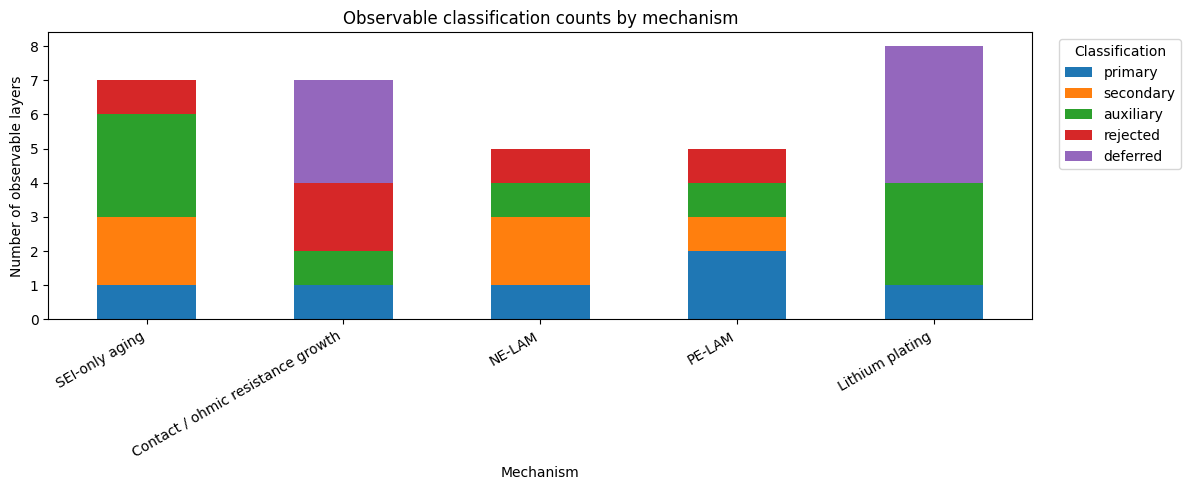

[OK] saved classification-count figure: /Users/louislu/projects/pybamm-aging-bridge/figures/cross_mechanism_classification_counts.png
[OK] saved docs classification-count figure: /Users/louislu/projects/pybamm-aging-bridge/docs/figures/cross_mechanism_classification_counts.png

[OK] Classification-count table:


classification,primary,secondary,auxiliary,rejected,deferred
mechanism,,,,,
SEI-only aging,1,2,3,1,0
Contact / ohmic resistance growth,1,0,1,2,3
NE-LAM,1,2,1,1,0
PE-LAM,2,1,1,1,0
Lithium plating,1,0,3,0,4



[OK] Primary-target count by mechanism:


,mechanism,n_primary_targets
0,SEI-only aging,1
1,Contact / ohmic resistance growth,1
2,NE-LAM,1
3,PE-LAM,2
4,Lithium plating,1



[BOUNDARY CHECKS]
[OK] Classification-count figure saved to both figures/ and docs/figures/.
[OK] Lithium plating primary count remains limited to direct mechanism-state observability.
[OK] Deferred plating external diagnostic layers remain visible.


In [6]:
# Cell 11 — Generate classification-count summary plot（生成分类数量汇总图）

classification_order = ["primary", "secondary", "auxiliary", "rejected", "deferred"]

count_df = (
    fingerprint_df
    .groupby(["mechanism", "classification"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=mechanism_order)
    .reindex(columns=classification_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))

count_df.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Observable classification counts by mechanism")
ax.set_xlabel("Mechanism")
ax.set_ylabel("Number of observable layers")
ax.legend(title="Classification", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

count_fig_path = fig_dir / "cross_mechanism_classification_counts.png"
count_docs_fig_path = docs_fig_dir / "cross_mechanism_classification_counts.png"

fig.savefig(count_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(count_docs_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"[OK] saved classification-count figure: {count_fig_path}")
print(f"[OK] saved docs classification-count figure: {count_docs_fig_path}")

print("\n[OK] Classification-count table:")
display(count_df)

# Overclaim audit
primary_counts = count_df["primary"].copy()

print("\n[OK] Primary-target count by mechanism:")
display(primary_counts.reset_index(name="n_primary_targets"))

assert primary_counts.loc["Lithium plating"] == 1, (
    "Lithium plating should have exactly one primary layer: direct mechanism-state variables."
)

assert count_df.loc["Lithium plating", "deferred"] >= 1, (
    "Lithium plating must retain deferred external diagnostic layers."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Classification-count figure saved to both figures/ and docs/figures/.")
print("[OK] Lithium plating primary count remains limited to direct mechanism-state observability.")
print("[OK] Deferred plating external diagnostic layers remain visible.")

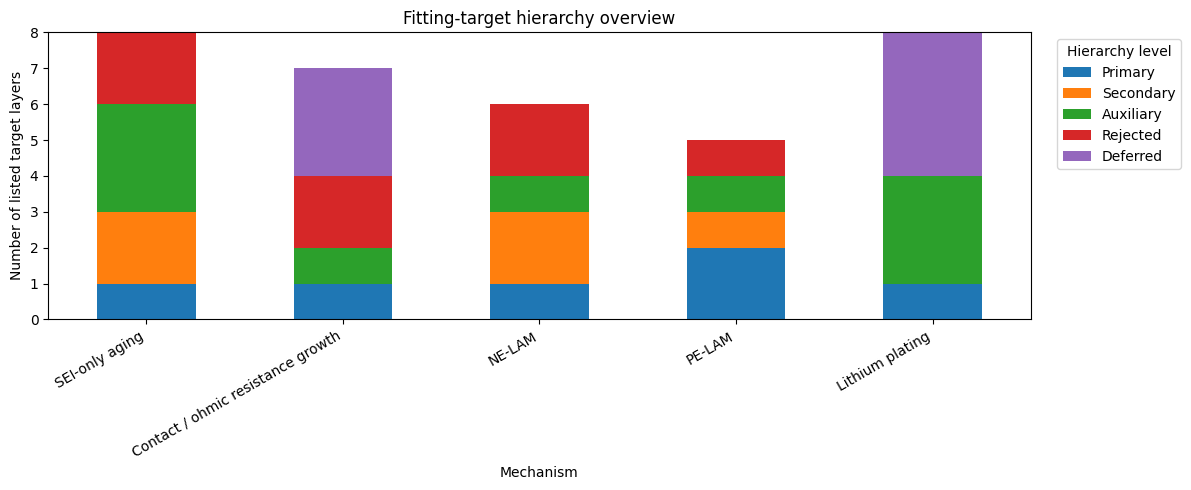

[OK] saved hierarchy overview figure: /Users/louislu/projects/pybamm-aging-bridge/figures/cross_mechanism_target_hierarchy_overview.png
[OK] saved docs hierarchy overview figure: /Users/louislu/projects/pybamm-aging-bridge/docs/figures/cross_mechanism_target_hierarchy_overview.png

[OK] Target hierarchy count table:


hierarchy_level,Primary,Secondary,Auxiliary,Rejected,Deferred
mechanism,,,,,
SEI-only aging,1,2,3,2,0
Contact / ohmic resistance growth,1,0,1,2,3
NE-LAM,1,2,1,2,0
PE-LAM,2,1,1,1,0
Lithium plating,1,0,3,0,4



[OK] Long-form hierarchy audit table:


,mechanism,hierarchy_level,n_items,raw_entry
0,SEI-only aging,Primary,1,Capacity RPT
1,SEI-only aging,Secondary,2,C/25 central-window V(Q); GITT-like finite-res...
2,SEI-only aging,Auxiliary,3,DVA central features; Ri(t); corrected relaxat...
3,SEI-only aging,Rejected,2,ICA central features; endpoint-only voltage drift
4,SEI-only aging,Deferred,0,None in current SEI-only branch
5,Contact / ohmic resistance growth,Primary,1,Multi-window Ri(t)
6,Contact / ohmic resistance growth,Secondary,0,None currently recommended
7,Contact / ohmic resistance growth,Auxiliary,1,Capacity RPT
8,Contact / ohmic resistance growth,Rejected,2,raw recovery amplitude; corrected relaxation d...
9,Contact / ohmic resistance growth,Deferred,3,C/25 central-window V(Q); ICA central features...



[OK] saved long-form hierarchy table: /Users/louislu/projects/pybamm-aging-bridge/data/cross_mechanism_target_hierarchy_long_v0_1.csv
[OK] saved docs long-form hierarchy table: /Users/louislu/projects/pybamm-aging-bridge/docs/tables/cross_mechanism_target_hierarchy_long_v0_1.csv

[BOUNDARY CHECKS]
[OK] Target hierarchy overview saved to both figures/ and docs/figures/.
[OK] Long-form hierarchy table saved for traceability.
[OK] Lithium plating still contains deferred external diagnostic layers.


In [7]:
# Cell 12 — Generate target hierarchy overview figure（生成拟合目标层级概览图）

hierarchy_long_rows = []

for _, row in target_hierarchy_df.iterrows():
    mechanism = row["mechanism"]
    for level, col in [
        ("Primary", "primary_targets"),
        ("Secondary", "secondary_targets"),
        ("Auxiliary", "auxiliary_layers"),
        ("Rejected", "rejected_features"),
        ("Deferred", "deferred_features"),
    ]:
        value = row[col]
        if value is None or pd.isna(value):
            n_items = 0
        elif str(value).strip().lower().startswith("none"):
            n_items = 0
        else:
            n_items = len([item.strip() for item in str(value).split(";") if item.strip()])
        hierarchy_long_rows.append(
            {
                "mechanism": mechanism,
                "hierarchy_level": level,
                "n_items": n_items,
                "raw_entry": value,
            }
        )

hierarchy_long_df = pd.DataFrame(hierarchy_long_rows)

hierarchy_count_df = (
    hierarchy_long_df
    .pivot_table(
        index="mechanism",
        columns="hierarchy_level",
        values="n_items",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=mechanism_order)
    .reindex(columns=["Primary", "Secondary", "Auxiliary", "Rejected", "Deferred"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
hierarchy_count_df.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Fitting-target hierarchy overview")
ax.set_xlabel("Mechanism")
ax.set_ylabel("Number of listed target layers")
ax.legend(title="Hierarchy level", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

hierarchy_fig_path = fig_dir / "cross_mechanism_target_hierarchy_overview.png"
hierarchy_docs_fig_path = docs_fig_dir / "cross_mechanism_target_hierarchy_overview.png"

fig.savefig(hierarchy_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(hierarchy_docs_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"[OK] saved hierarchy overview figure: {hierarchy_fig_path}")
print(f"[OK] saved docs hierarchy overview figure: {hierarchy_docs_fig_path}")

print("\n[OK] Target hierarchy count table:")
display(hierarchy_count_df)

print("\n[OK] Long-form hierarchy audit table:")
display(hierarchy_long_df)

# Save long-form audit table for traceability
hierarchy_long_data_path = data_dir / "cross_mechanism_target_hierarchy_long_v0_1.csv"
hierarchy_long_docs_path = docs_table_dir / "cross_mechanism_target_hierarchy_long_v0_1.csv"

hierarchy_long_df.to_csv(hierarchy_long_data_path, index=False)
hierarchy_long_df.to_csv(hierarchy_long_docs_path, index=False)

print(f"\n[OK] saved long-form hierarchy table: {hierarchy_long_data_path}")
print(f"[OK] saved docs long-form hierarchy table: {hierarchy_long_docs_path}")

# Boundary checks
assert hierarchy_fig_path.exists(), "Hierarchy overview figure was not saved to figures/."
assert hierarchy_docs_fig_path.exists(), "Hierarchy overview figure was not saved to docs/figures/."

plating_hierarchy = hierarchy_count_df.loc["Lithium plating"]
assert plating_hierarchy["Deferred"] > 0, (
    "Lithium plating must retain deferred diagnostic layers in target hierarchy overview."
)

print("\n[BOUNDARY CHECKS]")
print("[OK] Target hierarchy overview saved to both figures/ and docs/figures/.")
print("[OK] Long-form hierarchy table saved for traceability.")
print("[OK] Lithium plating still contains deferred external diagnostic layers.")

## 5. Repository-safe synthesis summary（仓库可见综合总结）

This block generates an English-only, company-neutral synthesis summary.

The summary is intended for repository documentation and documentation-ready portfolio use.

It must:

- summarize existing evidence only
- use company-neutral wording
- avoid organization-specific positioning
- avoid overclaiming lithium plating external diagnostics
- distinguish mechanism-state observability from measurement-accessible fitting targets
- preserve deferred claims explicitly

Output file:

- `docs/cross_mechanism_fingerprint_synthesis_v0_1.md`

In [8]:
# Cell 14 — Generate repository-safe synthesis summary（生成仓库可见综合总结）

summary_md = """# Cross-mechanism Fingerprint Synthesis v0.1

## Scope

This document summarizes the current mechanism-to-observable fingerprint framework for lithium-ion battery aging diagnostics and measurement-based aging-model parameterization.

The synthesis consolidates completed audit notebooks into a unified evidence structure. It does not introduce new simulations or new mechanism evidence.

Mechanism families covered in this version:

- SEI-only aging
- Contact / ohmic resistance growth
- Negative-electrode loss of active material
- Positive-electrode loss of active material
- Lithium plating

## Main objective

The objective is to identify which observable features are suitable as fitting targets for different aging mechanisms.

A measurable feature is not automatically a valid fitting target. The current framework separates primary targets, secondary targets, auxiliary audit layers, rejected features, and deferred features.

## Mechanism-level target hierarchy

| Mechanism | Current fingerprint classification | Primary target layer |
|---|---|---|
| SEI-only aging | Capacity-dominant, voltage-secondary, derivative-auxiliary | Capacity RPT |
| Contact / ohmic resistance growth | Ri(t)-dominant | Multi-window Ri(t) |
| Negative-electrode loss of active material | Capacity-dominant and boundary-sensitive | Capacity RPT |
| Positive-electrode loss of active material | Voltage-shape and DVA-dominant | C/25 central-window V(Q), DVA central features |
| Lithium plating | Direct mechanism-state observability supported; external diagnostic fingerprint deferred | Direct plating-state variables |

## Interpretation by mechanism

### SEI-only aging

SEI-only aging is currently classified as capacity-dominant. Capacity RPT provides the clearest primary fitting target in the completed audits.

C/25 central-window V(Q) and GITT-like finite-rest voltage provide secondary information, but voltage interpretation must avoid endpoint-amplified regions. ICA and DVA features remain auxiliary or rejected as primary targets under the current evidence because their derivative-level response is sensitive to preprocessing or weaker than capacity-level evidence.

### Contact / ohmic resistance growth

Contact / ohmic resistance growth is classified as Ri(t)-dominant. Multi-window Ri(t) provides the primary fitting target.

Raw recovery amplitude and raw recovery area are not valid primary relaxation descriptors because they are confounded by the instantaneous ohmic voltage jump. Post-ohmic corrected relaxation descriptors remain largely invariant in the completed audit and should not be interpreted as primary evidence of slow relaxation growth.

### Loss of active material

Negative-electrode loss of active material is capacity-dominant and boundary-sensitive. Capacity RPT is the primary target, while central-window voltage and DVA features provide secondary support when endpoint amplification is controlled.

Positive-electrode loss of active material is voltage-shape and DVA-dominant within the tested range. C/25 central-window V(Q) and DVA central features are the strongest current fitting-target candidates. Capacity RPT remains secondary.

### Lithium plating

Lithium plating direct mechanism-state observability is supported in the current model-based audit. Direct plating-state variables show stress sensitivity and matched-control separation.

This does not close the external diagnostic fingerprint. Capacity RPT, Ri(t), and corrected relaxation descriptors remain auxiliary under the current evidence. C/25 central-window V(Q), GITT-like finite-rest voltage, ICA features, and DVA features remain deferred until future process-isolated diagnostic audits support or reject them.

## Feature rejection and downgrade logic

A feature should not be used as a primary fitting target if one or more of the following risks dominate:

- endpoint amplification
- smoothing sensitivity
- weak matched-control separation
- mechanism non-uniqueness
- ohmic-jump confounding
- protocol sensitivity
- model-state-only observability
- execution-resource boundary

These rules are intended to prevent artifact-driven fitting and to keep fitting targets physically interpretable.

## Current conclusion

The project has moved from isolated mechanism notebooks to a structured mechanism-to-observable fingerprint framework.

The current evidence supports the following hierarchy:

- SEI-only aging: capacity-first
- Contact / ohmic resistance growth: Ri(t)-first
- Negative-electrode loss of active material: capacity-first with boundary control
- Positive-electrode loss of active material: voltage-shape and DVA-first
- Lithium plating: direct mechanism-state observability supported, external diagnostic fingerprint deferred

## Current limitations

This synthesis is evidence-conservative. It does not claim that all aging mechanisms are uniquely identifiable from one observable.

Capacity fade, voltage-shape drift, resistance increase, and derivative features can be mechanism-non-unique. Mechanism-specific interpretation requires contrast branches, matched controls, and protocol-boundary checks.

Lithium plating remains the most important open branch for external diagnostic closure.

## Recommended next step

The next useful technical step is targeted closure of deferred lithium-plating external diagnostics under process-isolated execution. Priority diagnostic layers are:

1. C/25 central-window V(Q)
2. GITT-like finite-rest voltage
3. ICA central features
4. DVA central features

Broad simulation sweeps are not recommended before these deferred diagnostic layers are closed.
"""

summary_path = docs_dir / "cross_mechanism_fingerprint_synthesis_v0_1.md"
summary_path.write_text(summary_md, encoding="utf-8")

print(f"[OK] saved repository-safe synthesis summary: {summary_path}")

print("\n[OK] Summary preview:")
print(summary_md[:2500])

# Save a traceability copy under data/
summary_audit_path = data_dir / "cross_mechanism_fingerprint_synthesis_v0_1.md"
summary_audit_path.write_text(summary_md, encoding="utf-8")

print(f"\n[OK] saved traceability copy: {summary_audit_path}")

print("\n[OK] File size audit:")
print(f"docs summary bytes: {summary_path.stat().st_size}")
print(f"data traceability copy bytes: {summary_audit_path.stat().st_size}")

assert summary_path.exists(), "Repository synthesis summary was not saved."
assert summary_audit_path.exists(), "Traceability copy was not saved."

print("\n[BOUNDARY CHECKS]")
print("[OK] Repository-safe synthesis summary generated.")
print("[OK] Summary states that no new simulation evidence is introduced.")
print("[OK] Lithium plating external diagnostic fingerprint remains deferred.")

[OK] saved repository-safe synthesis summary: /Users/louislu/projects/pybamm-aging-bridge/docs/cross_mechanism_fingerprint_synthesis_v0_1.md

[OK] Summary preview:
# Cross-mechanism Fingerprint Synthesis v0.1

## Scope

This document summarizes the current mechanism-to-observable fingerprint framework for lithium-ion battery aging diagnostics and measurement-based aging-model parameterization.

The synthesis consolidates completed audit notebooks into a unified evidence structure. It does not introduce new simulations or new mechanism evidence.

Mechanism families covered in this version:

- SEI-only aging
- Contact / ohmic resistance growth
- Negative-electrode loss of active material
- Positive-electrode loss of active material
- Lithium plating

## Main objective

The objective is to identify which observable features are suitable as fitting targets for different aging mechanisms.

A measurable feature is not automatically a valid fitting target. The current framework separates prim

In [9]:
# Cell 15 — Audit repository-safe summary and claim boundaries（审计仓库可见总结与结论边界）

summary_text = summary_path.read_text(encoding="utf-8")

print("[AUDIT] Repository synthesis summary path:")
print(summary_path)

print("\n[AUDIT] Summary length:")
print(f"{len(summary_text)} characters")

required_boundary_phrases = [
    "mechanism-to-observable fingerprint framework",
    "does not introduce new simulations",
    "external diagnostic fingerprint deferred",
    "mechanism-state observability",
    "artifact-driven fitting",
]

missing_required_phrases = [
    phrase for phrase in required_boundary_phrases
    if phrase.lower() not in summary_text.lower()
]

assert not missing_required_phrases, (
    f"Missing required boundary phrases: {missing_required_phrases}"
)

# Lithium-plating overclaim audit
plating_required_phrases = [
    "Direct plating-state variables",
    "does not close the external diagnostic fingerprint",
    "remain deferred",
    "process-isolated diagnostic audits",
]

missing_plating_phrases = [
    phrase for phrase in plating_required_phrases
    if phrase.lower() not in summary_text.lower()
]

assert not missing_plating_phrases, (
    f"Missing lithium-plating boundary phrases: {missing_plating_phrases}"
)

# Repository-safe style audit: avoid internal process or career-positioning terms
non_repository_terms = [
    "application letter",
    "job application",
    "interview preparation",
    "private planning",
    "notion planning",
]

non_repository_hits = [
    term for term in non_repository_terms
    if term.lower() in summary_text.lower()
]

assert not non_repository_hits, (
    f"Non-repository terms found in synthesis summary: {non_repository_hits}"
)

# Documentation output inventory audit
expected_doc_outputs = [
    docs_table_dir / "cross_mechanism_fingerprint_matrix_v0_1.csv",
    docs_table_dir / "cross_mechanism_target_hierarchy_v0_1.csv",
    docs_table_dir / "cross_mechanism_rejection_flags_v0_1.csv",
    docs_table_dir / "cross_mechanism_target_hierarchy_long_v0_1.csv",
    docs_fig_dir / "cross_mechanism_fingerprint_heatmap.png",
    docs_fig_dir / "cross_mechanism_classification_counts.png",
    docs_fig_dir / "cross_mechanism_target_hierarchy_overview.png",
    docs_dir / "cross_mechanism_fingerprint_synthesis_v0_1.md",
]

missing_outputs = [p for p in expected_doc_outputs if not p.exists()]

assert not missing_outputs, (
    "Missing expected documentation outputs:\n" + "\n".join(str(p) for p in missing_outputs)
)

print("\n[OK] Required boundary phrases are present.")
print("[OK] Lithium-plating overclaim audit passed.")
print("[OK] Repository-safe wording audit passed.")
print("[OK] All expected documentation outputs exist.")

print("\n[OK] Documentation output inventory:")
for path in expected_doc_outputs:
    print(f"- {path.relative_to(repo)}")

[AUDIT] Repository synthesis summary path:
/Users/louislu/projects/pybamm-aging-bridge/docs/cross_mechanism_fingerprint_synthesis_v0_1.md

[AUDIT] Summary length:
5613 characters

[OK] Required boundary phrases are present.
[OK] Lithium-plating overclaim audit passed.
[OK] Repository-safe wording audit passed.
[OK] All expected documentation outputs exist.

[OK] Documentation output inventory:
- docs/tables/cross_mechanism_fingerprint_matrix_v0_1.csv
- docs/tables/cross_mechanism_target_hierarchy_v0_1.csv
- docs/tables/cross_mechanism_rejection_flags_v0_1.csv
- docs/tables/cross_mechanism_target_hierarchy_long_v0_1.csv
- docs/figures/cross_mechanism_fingerprint_heatmap.png
- docs/figures/cross_mechanism_classification_counts.png
- docs/figures/cross_mechanism_target_hierarchy_overview.png
- docs/cross_mechanism_fingerprint_synthesis_v0_1.md


## Final closure（最终闭合）

### Key findings

This notebook consolidated the completed aging-mechanism audits into a cross-mechanism fingerprint synthesis.

The resulting mechanism-to-observable hierarchy is:

| Mechanism | Supported primary layer |
|---|---|
| SEI-only aging | Capacity RPT |
| Contact / ohmic resistance growth | Multi-window Ri(t) |
| NE-LAM | Capacity RPT |
| PE-LAM | C/25 central-window V(Q), DVA central features |
| Lithium plating | Direct plating-state variables |

The synthesis confirms that different aging mechanisms should not be fitted using a single universal diagnostic feature. Instead, each mechanism requires a distinct target hierarchy.

The notebook generated:

- `data/cross_mechanism_fingerprint_matrix_v0_1.csv`
- `data/cross_mechanism_target_hierarchy_v0_1.csv`
- `data/cross_mechanism_rejection_flags_v0_1.csv`
- `data/cross_mechanism_target_hierarchy_long_v0_1.csv`
- `data/cross_mechanism_fingerprint_synthesis_v0_1.md`
- `docs/tables/cross_mechanism_fingerprint_matrix_v0_1.csv`
- `docs/tables/cross_mechanism_target_hierarchy_v0_1.csv`
- `docs/tables/cross_mechanism_rejection_flags_v0_1.csv`
- `docs/tables/cross_mechanism_target_hierarchy_long_v0_1.csv`
- `docs/figures/cross_mechanism_fingerprint_heatmap.png`
- `docs/figures/cross_mechanism_classification_counts.png`
- `docs/figures/cross_mechanism_target_hierarchy_overview.png`
- `docs/cross_mechanism_fingerprint_synthesis_v0_1.md`

### Supported conclusions

SEI-only aging is supported as a capacity-dominant branch. Capacity RPT is the strongest current fitting target, while voltage and derivative layers remain secondary or auxiliary.

Contact / ohmic resistance growth is supported as a Ri(t)-dominant branch. Multi-window Ri(t) is the correct primary target layer.

NE-LAM is supported as a capacity-dominant and boundary-sensitive branch. Capacity RPT is the primary target, while voltage-shape and DVA features require endpoint control.

PE-LAM is supported as a voltage-shape and DVA-dominant branch within the tested range. C/25 central-window V(Q) and DVA central features are the strongest current fitting-target candidates.

### Partially supported conclusions

Voltage-shape and derivative features are useful, but their interpretation depends on central-window control, smoothing sensitivity checks, and mechanism-contrast evidence.

Capacity fade is a strong observable but not mechanism-unique. It must be combined with other target layers when mechanism separation is required.

### Unsupported / deferred claims

Lithium plating external diagnostic fingerprint closure is deferred.

Direct plating-state variables are supported as mechanism-state observables in the model-based audit, but they are not equivalent to measurement-accessible fitting targets.

C/25 central-window V(Q), GITT-like finite-rest voltage, ICA features, and DVA features under lithium plating remain open diagnostic layers.

ICA peak features are not supported as primary fitting targets in the current framework.

Raw recovery amplitude is not supported as a primary relaxation descriptor for contact / ohmic resistance growth because it is ohmic-jump-confounded.

### Execution or protocol boundaries

This notebook did not run new PyBaMM simulations.

The synthesis is based on completed mechanism audits and therefore does not create new mechanism evidence.

The generated documentation uses company-neutral wording and avoids organization-specific positioning.

Lithium plating HPPC and external diagnostic layers require process-isolated execution in future work because dense model-state workflows can exceed notebook execution limits.

### Correct conclusion wording

The current project state supports a mechanism-specific fitting-target hierarchy for lithium-ion battery aging diagnostics:

- SEI-only aging: capacity-first
- Contact / ohmic resistance growth: Ri(t)-first
- NE-LAM: capacity-first with endpoint-boundary control
- PE-LAM: voltage-shape and DVA-first
- Lithium plating: direct mechanism-state observability supported; external diagnostic fingerprint deferred

This synthesis should be interpreted as a conservative evidence map, not as proof that every mechanism is uniquely identifiable from one observable.

### Next step

The next recommended notebook is a targeted lithium-plating external diagnostic closure audit.

Priority layers:

1. C/25 central-window V(Q)
2. GITT-like finite-rest voltage
3. ICA central features
4. DVA central features

The next workflow should remain process-isolated where dense PyBaMM solution objects or HPPC-like diagnostic protocols create notebook execution risk.